In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

# 0. Задача анализа

Классификация сортов вин (три класса) на основе 13 химических показателей. Цель - понять, какие признаки наиболее информативны для разделения классов, выявить возможные выбросы и особенности данных, которые помогут при построении модели классификации.

# 1. Загрузка данных и первичный анализ

In [3]:
# Загрузка данных
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Основная информация
print("Размер данных:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПервые 5 строк:")
print(df.head())
print("\nПропущенные значения:")
print(df.isnull().sum())

Размер данных: (178, 14)

Типы данных:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Первые 5 строк:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0    

# 2. Описательные статистики

In [4]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


# 3. Анализ распределений признаков

## 3.1 Гистограммы

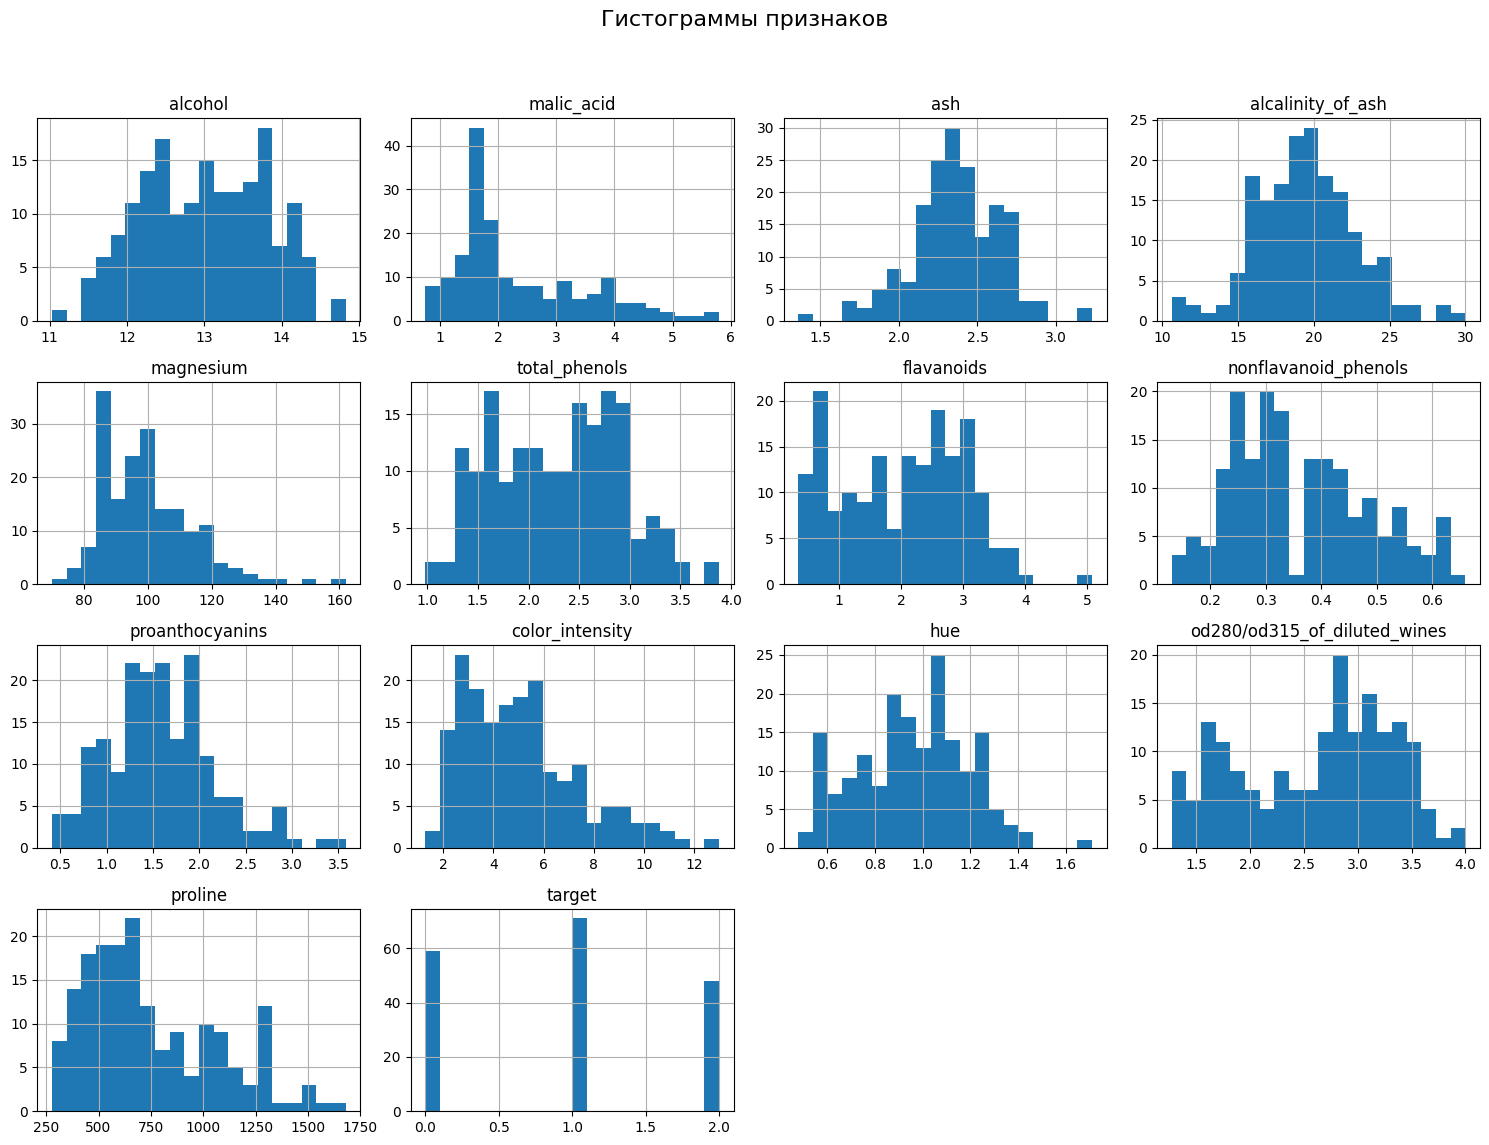

In [5]:
df.hist(bins=20, figsize=(15, 12))
plt.suptitle('Гистограммы признаков', size=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Анализ гистограм:
- Alcohol - распределение близко к нормальному, небольшая правосторонняя асимметрия.
- Malic_acid - распределение скошено вправо, есть длинный хвост, что указывает на наличие образцов с высокими значениями.
- Ash - приблизительно симметричное распределение, близкое к нормальному.
- Alcalinity_of_ash - распределение симметричное, без ярко выраженной асимметрии.
- Magnesium - заметная правосторонняя асимметрия, несколько пиков, что может быть связано с различными сортами вин.
- Total_phenols - распределение близко к нормальному, небольшой левосторонний скос.
- Flavanoids - распределение бимодальное, что отражает различия между классами вин.
- Nonflavanoid_phenols - распределение скошено вправо, большинство значений сосредоточено в низкой области.
- Proanthocyanins - распределение симметричное, близкое к нормальному.
- Color_intensity - сильная правосторонняя асимметрия, есть образцы с очень высокой интенсивностью цвета.
- Hue - распределение близко к нормальному, небольшой левосторонний скос.
- OD280/OD315 - распределение симметричное, возможно, бимодальное.
- Proline - распределение сильно скошено вправо, большинство значений сосредоточено в диапазоне 500-1000, но присутствуют выбросы до 1680.

В целом, многие признаки имеют скошенные распределения, что может потребовать преобразований (логарифмирование, стандартизация) перед построением моделей.

## 3.2 box plots

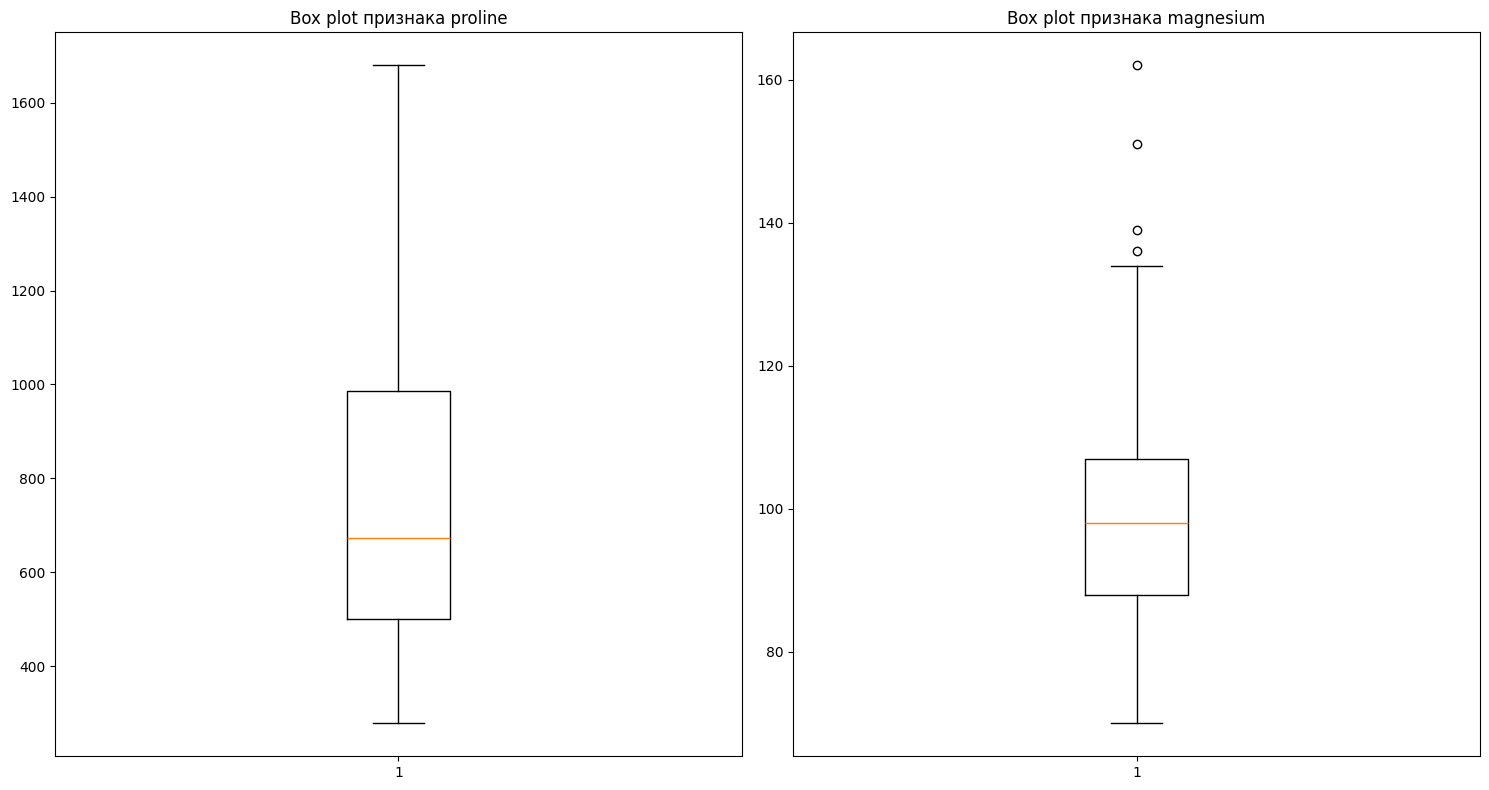

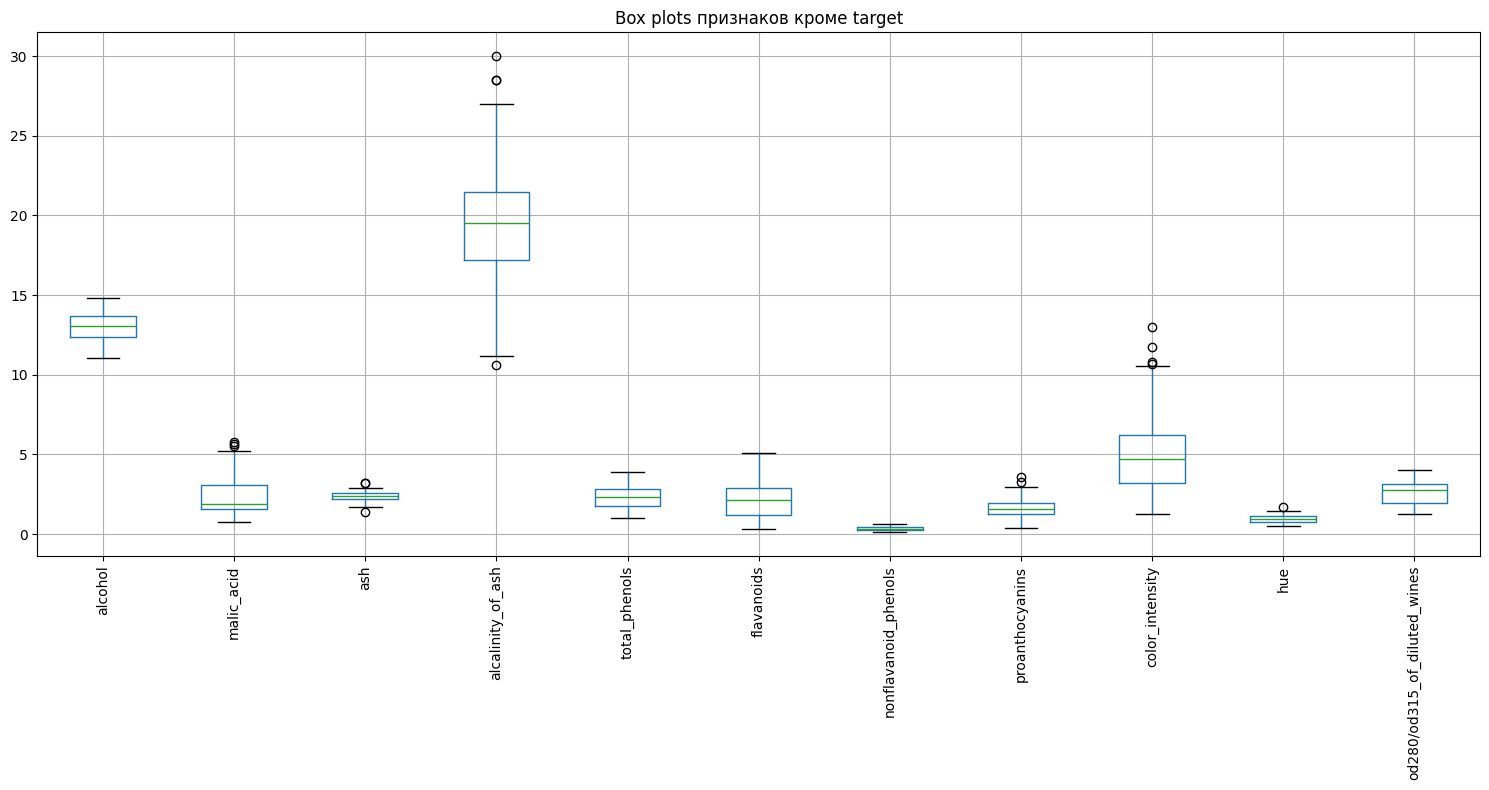

In [6]:
proline_df = df["proline"]
magnesium_df = df["magnesium"]
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.title('Box plot признака proline')
plt.boxplot(proline_df)
plt.subplot(1, 2, 2)
plt.title('Box plot признака magnesium')
plt.boxplot(magnesium_df)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
plt.title('Box plots признаков кроме target')
df.drop(["magnesium", "proline", "target"], axis=1).boxplot(rot=90)
plt.tight_layout()
plt.show()

Анализ Box plot-ов:
- malic_acid - несколько выбросов сверху верхней границы.
- ash - несколько выбросов сверху верхней границы и снизу нижней границы.
- alcalinity_of_ash - несколько выбросов сверху верхней границы и снизу нижней границы.
- magnesium - несколько выбросов сверху верхней границы.
- proanthocyanins - несколько выбросов сверху верхней границы.
- color_intensity - несколько выбросов сверху верхней границы.
- hue - выброс сверху верхней границы.
- остальные без выбросов.

Наличие выбросов может указывать на редкие сорта вин или особенности химического состава.

# 4. Двумерный анализ

## 4.1 Корреляционная матрица

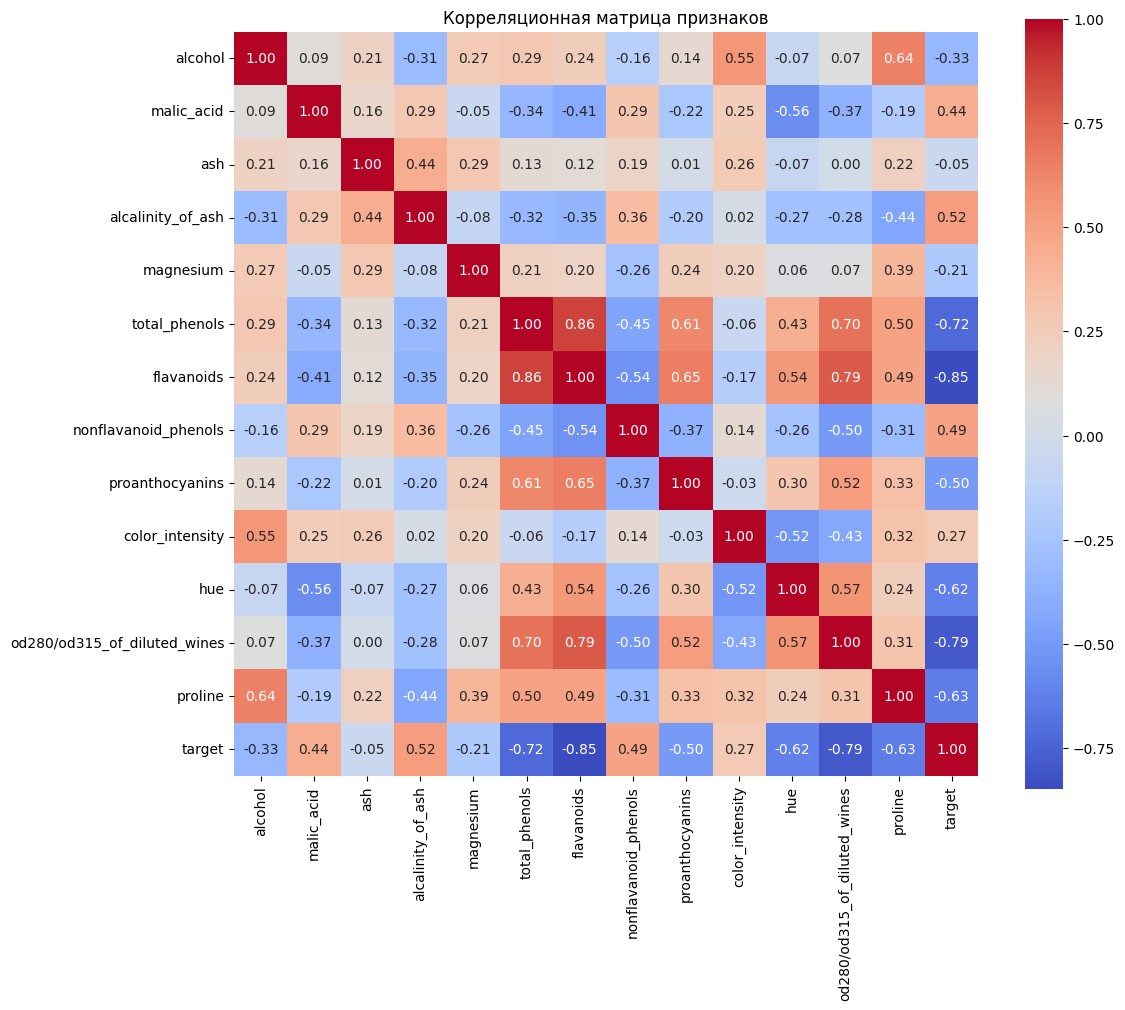

In [7]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица признаков')
plt.show()

Анализ корелляции:
- Total_phenols и flavanoids (коэффициент около 0.86) - ожидаемо, так как флавоноиды являются подклассом фенолов.
- Flavanoids и OD280/OD315 (около 0.79) - отражает связь с оптическими свойствами вина.
- Total_phenols и OD280/OD315 (около 0.70).
- Proline и alcohol (около 0.64) - умеренная положительная связь.
- Color_intensity отрицательно коррелирует с hue (около -0.52) и с flavanoids (около -0.55).
- С целевой переменной target наиболее сильно коррелируют flavanoids (около -0.85), total_phenols (-0.72), OD280/OD315 (-0.79) и proline (-0.63). Это говорит о том, что эти признаки наиболее важны для разделения сортов вин.

## 4.2 Матрица рассеяния для выбранных признаков

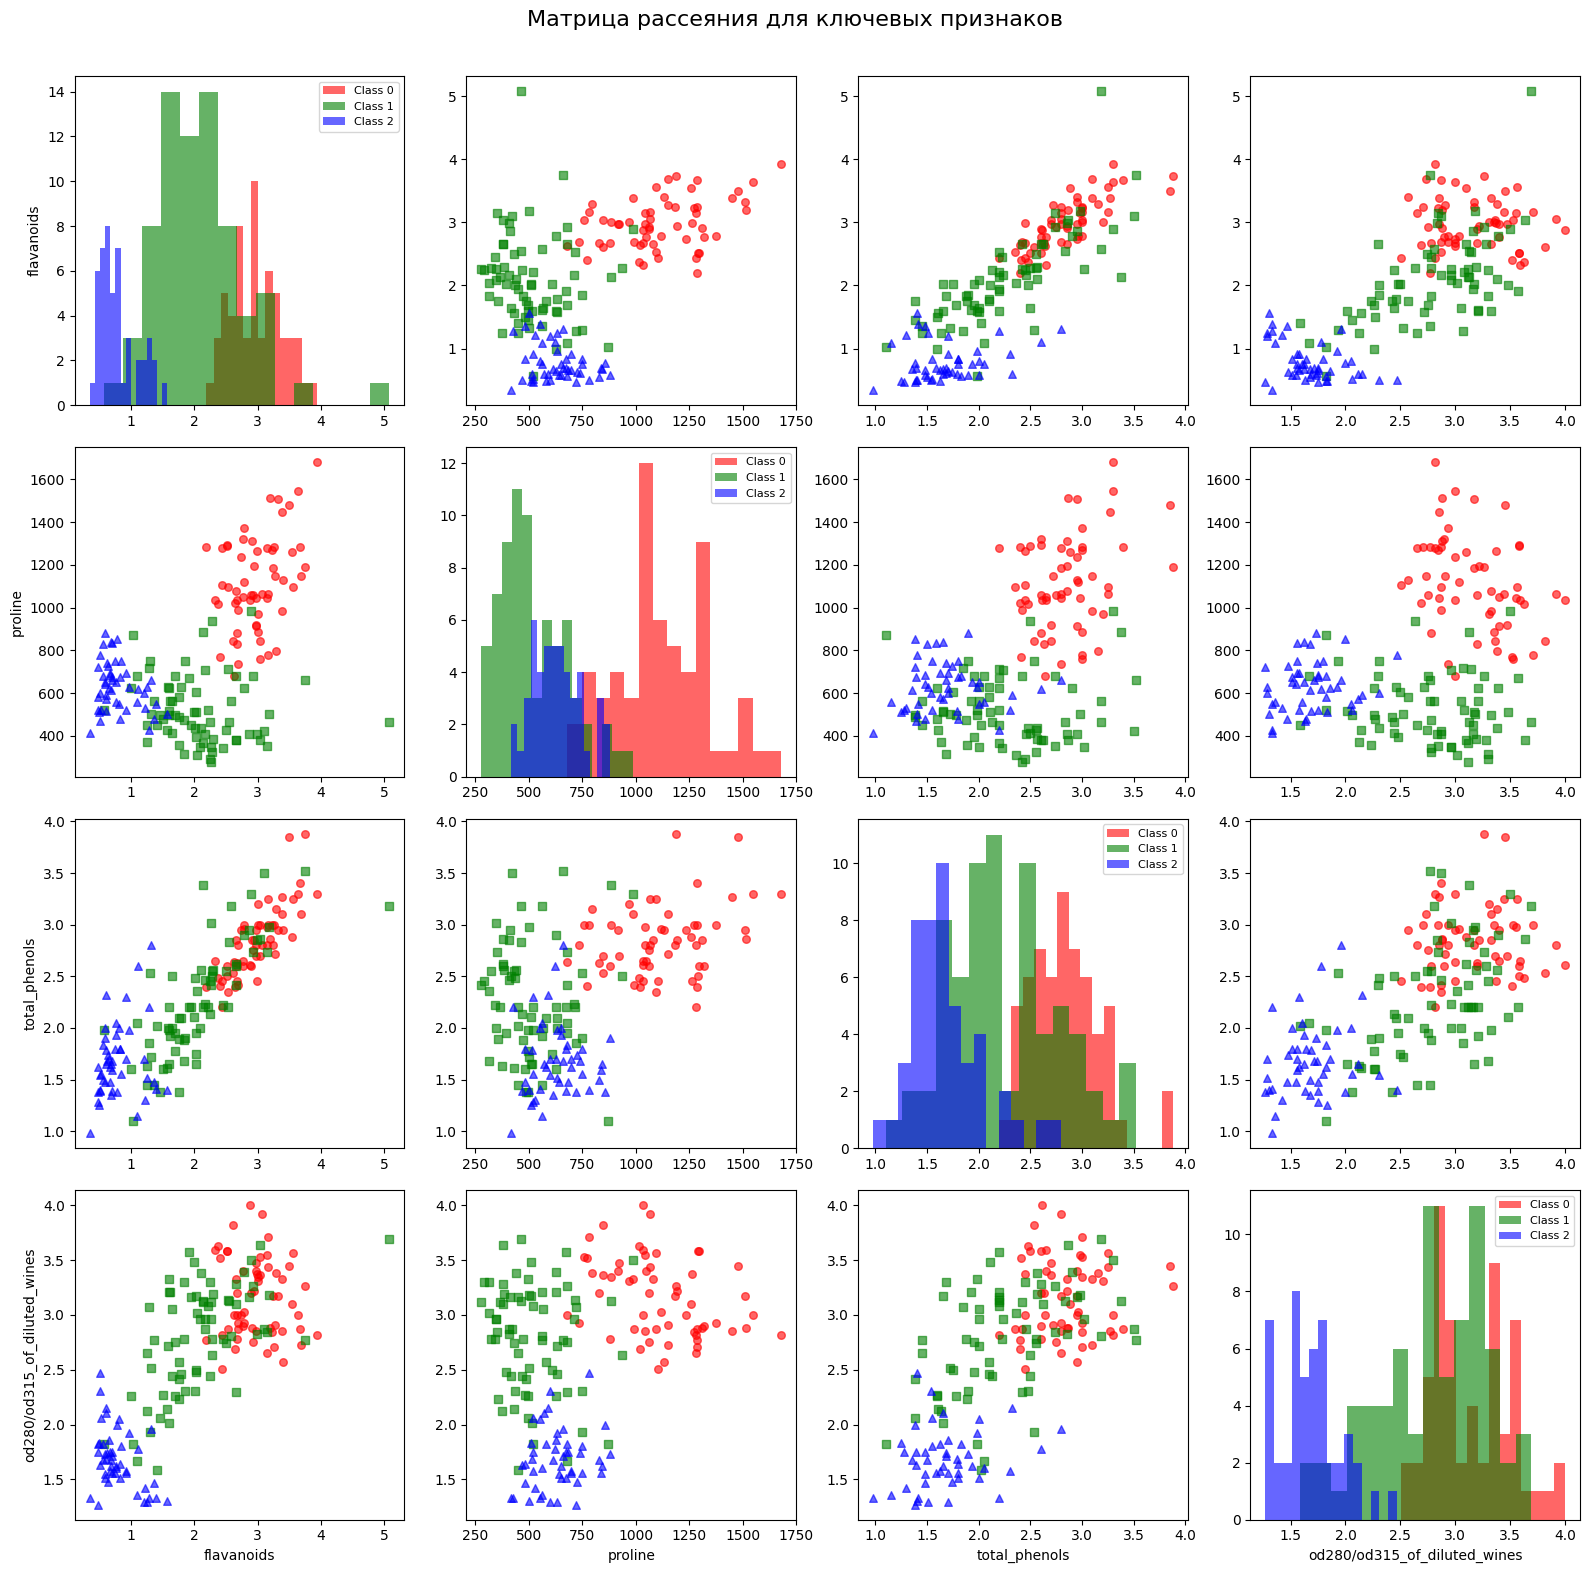

In [8]:
selected_features = ['flavanoids', 'proline', 'total_phenols', 'od280/od315_of_diluted_wines']
colors = ['red', 'green', 'blue']
markers = ['o', 's', '^']

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, feat_i in enumerate(selected_features):
    for j, feat_j in enumerate(selected_features):
        ax = axes[i, j]
        if i == j:
            # На диагонали гистограмма
            for k in range(3):
                subset = df[df['target'] == k]
                ax.hist(subset[feat_i], bins=15, alpha=0.6, color=colors[k], label=f'Class {k}')
            ax.legend(loc='best', fontsize=8)
        else:
            for k in range(3):
                subset = df[df['target'] == k]
                ax.scatter(subset[feat_j], subset[feat_i], alpha=0.6, c=colors[k], marker=markers[k], s=30)
        if i == 3:
            ax.set_xlabel(feat_j, fontsize=10)
        if j == 0:
            ax.set_ylabel(feat_i, fontsize=10)
plt.suptitle('Матрица рассеяния для ключевых признаков', size=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Анализ матрицы рассеяния:
- flavanoids: На гистограмме видно четкое разделение классов. Класс 0 имеет высокие значения флавоноидов (в основном от 2.5 до 4.0), класс 1 - средние (от 1.5 до 2.5), класс 2 - низкие (менее 1.0). Это один из самых информативных признаков.
- proline: Класс 0 характеризуется очень высокими значениями пролина (более 1000), класс 1 - средними (от 500 до 800), класс 2 - низкими (менее 600). Признак также хорошо разделяет классы, особенно класс 0.
- total_phenols: Распределение похоже на flavanoids: класс 0 - высокие значения (более 2.5), класс 1 - средние (от 2.0 до 3.0), класс 2 - низкие (менее 2.0). Разделение хорошее, но есть небольшое перекрытие между классами 1 и 2.
- od280/od315_of_diluted_wines: Класс 0 имеет высокие значения (более 3.0), класс 1 - средние (от 2.5 до 3.2), класс 2 - низкие (менее 2.5). Также хорошо разделяет классы.

Рассмотрим парные зависимости:
- flavanoids vs total_phenols: Наблюдается сильная положительная корреляция. Точки классов образуют три четкие группы вдоль линии тренда, что подтверждает высокую информативность обоих признаков.
- flavanoids vs od280/od315: Также сильная положительная связь. Классы хорошо разделяются, особенно класс 2 (низкие значения обоих признаков).
- flavanoids vs proline: Здесь классы также разделяются, но разброс внутри классов больше. Класс 0 имеет высокие значения обоих признаков, класс 2 - низкие.
- proline vs total_phenols: Подобно предыдущему, классы различимы, но наблюдается некоторое перекрытие.
- proline vs od280/od315: Хорошее разделение, особенно класса 0 (высокий пролин и высокий OD280/OD315).
- total_phenols vs od280/od315: Сильная корреляция, классы разделяются четко.

В целом, все четыре признака обладают высокой разделяющей способностью. Наилучшее разделение достигается при использовании пар flavanoids - total_phenols и flavanoids - od280/od315, где классы формируют компактные и хорошо отделимые кластеры. Признак proline особенно полезен для идентификации класса 0. Матрица рассеяния подтверждает, что для классификации сортов вин достаточно использовать небольшое количество наиболее информативных признаков.

# 5. Преобразование данных

Признаки имеют разные единицы измерения и масштабы (например, proline имеет значения от 278 до 1680, а alcohol - от 11 до 15). Для многих алгоритмов машинного обучения потребуется стандартизация или нормализация. В рамках разведочного анализа логарифмирование не требуется, но может быть применено для сглаживания асимметрии (например, для proline). Однако в данном случае оставим данные без преобразований, так как цель - визуальный анализ.

# 6. Ответы на поставленные вопросы

1) Есть ли выбросы в данных. Если да, укажите в каких атрибутах.

*Ответ:* Да, в данных присутствуют выбросы. Анализ box plots (раздел 3.2) позволил выявить следующие атрибуты, содержащие выбросы: malic_acid, ash, alcalinity_of_ash, magnesium, proanthocyanins, color_intensity, hue, proline.

2) Если набор данных относится к киберфизическим данным, если переходный период, в течение которой система выходит на режим. Если да, укажите его длительность (можно указать число записей, которые описывают этот переходный период).

*Ответ:* Нет, данный набор данных не является киберфизическим. Это классический набор данных для задач классификации (wine dataset), который содержит химические характеристики различных образцов вин, собранные в определённый момент времени. Данные не представляют собой временной ряд или последовательность измерений от начала работы какой-либо системы, поэтому понятие «переходного периода» к ним неприменимо. Все записи являются независимыми наблюдениями.

3) Определите, какие атрибуты наиболее интересны для решения задачи классификации. Объясните почему.

*Ответ:* Наиболее информативными для разделения трёх сортов вин являются следующие признаки:
- flavanoids (флавоноиды)
- total_phenols (общее содержание фенолов)
- od280/od315_of_diluted_wines (оптическая плотность при длинах волн 280/315 нм)
- proline (пролин)

Обоснование:
1) Корреляция с целевой переменной (раздел 4.1).

Эти признаки имеют самые высокие по модулю коэффициенты корреляции с классом вина:
- flavanoids: -0.85
- total_phenols: -0.72
- od280/od315_of_diluted_wines: -0.79
- proline: -0.63

Высокая (отрицательная) корреляция указывает на сильную связь с сортом (на самом деле в данной задаче нет разницы между положительной и отрицательной, важно только высокое численное значение).

2) Разделение классов на графиках (раздел 4.2).

Матрица рассеяния для этих четырёх признаков демонстрирует чёткую кластеризацию образцов по трём классам. Например:
- Класс 0 имеет высокие значения flavanoids, total_phenols и proline.
- Класс 2 характеризуется низкими значениями этих же признаков.
- Класс 1 занимает промежуточное положение.

Парные зависимости, такие как flavanoids vs total_phenols или flavanoids vs od280/od315, показывают хорошо отделимые группы без значительного перекрытия.

3) Физико-химический смысл.

Эти признаки отражают ключевые различия в составе вин разных сортов: содержание фенольных соединений (флавоноиды, общие фенолы) и аминокислоты пролина влияют на вкус, цвет и другие органолептические свойства, что естественным образом различается для разных сортов.